**EDA по Diabetes 130-US Hospitals for Years 1999–2008**


**diabetic_data.csv** - основной датасет

**IDS_mapping.csv** - расшифровка кодов admission_type_id (Тип поступления в больницу), discharge_disposition_id (Куда выписан пациент), admission_source_id (Откуда поступил пациент)

Признаки по основному датасету

**encounter_id** - ID госпитализации

**patient_nbr** - ID пациента


***Демография***

**race** - Раса пациента   

**gender** - Пол

**age** - Возрастная группа

**weight** - Вес

**time_in_hospital** - количество дней в больнице

***Плательщик и специальность врача***

**payer_code** - код страховой компании / плательщика

**medical_specialty** - Специальность лечащего / принимающего врача

***Количество процедур, лекарств, диагнозов***

**num_lab_procedures** - Количество лабораторных процедур

**num_procedures**	Количество нелабораторных процедур

**num_medications** -	Количество назначенных препаратов

**number_outpatient** -	Количество outpatient-визитов за предыдущий год

**number_emergency** - Количество emergency-визитов за предыдущий год

**number_inpatient**	Количество inpatient-госпитализаций за предыдущий год

**number_diagnoses** - Количество диагнозов

***Диагнозы***

**diag_1** - Основной диагноз

**diag_2** - Вторичный диагноз

**diag_3** - Дополнительный диагноз

***Лабораторные показатели***

**max_glu_serum** - Уровень глюкозы в крови: Norm / >200 / >300

**A1Cresult** - Гликированный гемоглобин: Norm / >7 / >8

***Препараты***

Для каждого препарата указано, как изменилась дозировка во время госпитализации

**metformin**	- Метформин

**repaglinide**	- Репаглинид

**nateglinide**	- Натеглинид

**chlorpropamide** - Хлорпропамид

**glimepiride**	- Глимепирид

**acetohexamide**	- Ацетогексамид

**glipizide**	- Глипизид

**glyburide**	- Глибурид

**tolbutamide**	- Толбутамид

**pioglitazone**	- Пиоглитазон

**rosiglitazone**	- Росиглитазон

**acarbose**	- Акарбоза

**miglitol**	- Миглитол

**troglitazone** -	Троглитазон

**tolazamide** - Толазамид

**examide**	- Экзамид

**citoglipton**	- Цитоглиптон

**insulin**	- Инсулин

**glyburide-metformin**	- Комбинация глибурида и метформина

**glipizide-metformin**	- Комбинация глипизида и метформина

**glimepiride-pioglitazone**	- Комбинация глимепирида и пиоглитазона

**metformin-rosiglitazone**	- Комбинация метформина и росиглитазона

**metformin-pioglitazone** - Комбинация метформина и пиоглитазона

***Общие признаки по лечению диабета***

**change** - Было ли изменение диабетического лечения Ch — да, No — нет

**diabetesMed** - Назначались ли диабетические препараты Yes / No

**readmitted** - Была ли повторная госпитализация и когда

In [415]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [416]:
data = pd.read_csv('./data/diabetic_data.csv')

In [417]:
data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [418]:
data.shape

(101766, 50)

In [419]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

В датасете больше 100 тысяч наблюдений. Одна строка соответствует одному случаю госпитализации, а не обязательно одному уникальному пациенту

целевая - readmitted

показывает был ли пациент повторно госпитализирован (no, >30, <30)

**пропуски**

много колонок с "?"

In [420]:
marks = (data == '?').sum().sort_values(ascending=False)
marks[marks > 0]

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [421]:
data = data.replace('?', np.nan)

In [422]:
missing_percent = data.isna().mean().sort_values(ascending=False) * 100
missing_percent

weight                      96.858479
max_glu_serum               94.746772
A1Cresult                   83.277322
medical_specialty           49.082208
payer_code                  39.557416
race                         2.233555
diag_3                       1.398306
diag_2                       0.351787
diag_1                       0.020636
encounter_id                 0.000000
troglitazone                 0.000000
tolbutamide                  0.000000
pioglitazone                 0.000000
rosiglitazone                0.000000
acarbose                     0.000000
miglitol                     0.000000
citoglipton                  0.000000
tolazamide                   0.000000
examide                      0.000000
glipizide                    0.000000
insulin                      0.000000
glyburide-metformin          0.000000
glipizide-metformin          0.000000
glimepiride-pioglitazone     0.000000
metformin-rosiglitazone      0.000000
metformin-pioglitazone       0.000000
change      

In [423]:
missing_percent[missing_percent > 0]

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

In [424]:
df = data.copy()
df = df.drop(columns=['weight', 'max_glu_serum', 'A1Cresult'])

In [425]:
df.shape

(101766, 47)

In [426]:
df = df.drop(columns=['encounter_id'])

In [427]:
df = df.drop(columns=['payer_code', 'medical_specialty'])

**дубликаты**

In [428]:
df.duplicated().sum()

np.int64(0)

In [429]:
len(df), df['patient_nbr'].nunique()

(101766, 71518)

In [430]:
patient_counts = df['patient_nbr'].value_counts()

patient_counts.head()

patient_nbr
88785891    40
43140906    28
1660293     23
23199021    23
88227540    23
Name: count, dtype: int64

некоторые пациенты встречаются несколько раз, значит один пациент мог быть госпитализирован несколько раз

**Удаление некорректного пола**

In [431]:
df['gender'].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

**Удаление случаев смерти и хосписа**

Если пациент умер или был переведён в хоспис, то отсутствие повторной госпитализации нельзя сравнивать с обычными пациентами

Такие случаи закодированы в discharge_disposition_id

In [432]:
death_or_hospice = [11, 13, 14, 19, 20, 21]

df = df[~df['discharge_disposition_id'].isin(death_or_hospice)]

In [433]:
df.shape

(99343, 44)

**Удаление лекарств, которые почти всегда равны No**

In [434]:
medicine_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

medicine_cols = [col for col in medicine_cols if col in df.columns]

Посчитаем долю No по каждому препарату

In [435]:
no_table = pd.DataFrame({'no_percent': (df[medicine_cols] == 'No').mean() * 100, 'unique_values': df[medicine_cols].nunique()}).sort_values('no_percent', ascending=False)

no_table

,no_percent,unique_values
citoglipton,100.000000,1
examide,100.000000,1
metformin-pioglitazone,99.998993,2
glimepiride-pioglitazone,99.998993,2
acetohexamide,99.998993,2
metformin-rosiglitazone,99.997987,2
troglitazone,99.996980,2
glipizide-metformin,99.986914,2
tolbutamide,99.978861,2
miglitol,99.961749,4


Удалим признаки, где больше 99% значений no

In [436]:
no_limit = 99

low_information_medicine_cols = no_table[no_table['no_percent'] > no_limit].index.tolist()

low_information_medicine_cols

['citoglipton',
 'examide',
 'metformin-pioglitazone',
 'glimepiride-pioglitazone',
 'acetohexamide',
 'metformin-rosiglitazone',
 'troglitazone',
 'glipizide-metformin',
 'tolbutamide',
 'miglitol',
 'tolazamide',
 'chlorpropamide',
 'acarbose',
 'nateglinide',
 'glyburide-metformin']

In [437]:
df = df.drop(columns=low_information_medicine_cols)

In [438]:
df.shape

(99343, 29)

**Целевая переменная readmitted**

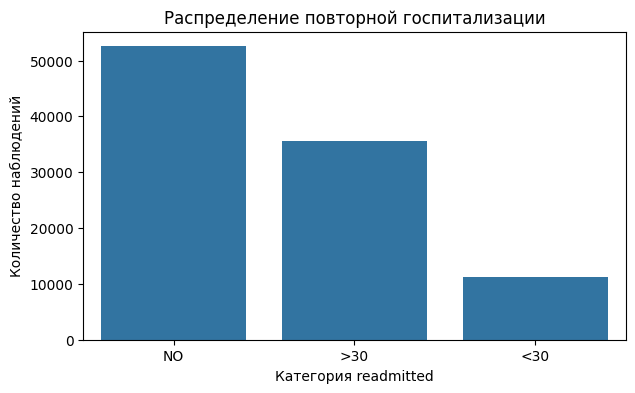

In [439]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x='readmitted', order=['NO', '>30', '<30'])

plt.title('Распределение повторной госпитализации')
plt.xlabel('Категория readmitted')
plt.ylabel('Количество наблюдений')

plt.show()

Рассмотрим причины ранней повторной госпитализации

readmitted_30 = 1 - пациент вернулся в больницу в течение 30 дней
readmitted_30 = 0 - пациент не вернулся в течение 30 дней

In [440]:
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)
df['readmitted_any'] = (df['readmitted'] != 'NO').astype(int)

**Анализ возраста и пола**

Так как в исходном датасете одна строка соответствует госпитализации, один и тот же пациент может встречаться несколько раз.

Поэтому для анализа возраста и пола я создам отдельную таблицу на уровне уникальных пациентов. В ней каждый patient_nbr будет встречаться только один раз.

Для пола и возраста беру первое встреченное значение пациента, а для readmitted_30 использую максимум:
если у пациента хотя бы однажды была ранняя повторная госпитализация, значение будет 1.

In [441]:
patient_demo = (df.groupby('patient_nbr').agg(age=('age', 'first'), gender=('gender', 'first'), readmitted_30=('readmitted_30', 'max')).reset_index())

In [442]:
patient_demo.head()

,patient_nbr,age,gender,readmitted_30
0,135,[50-60),Female,1
1,378,[50-60),Female,0
2,729,[80-90),Female,0
3,774,[80-90),Female,0
4,927,[30-40),Female,0


In [443]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

patient_demo['age'] = pd.Categorical(patient_demo['age'], categories=age_order, ordered=True)

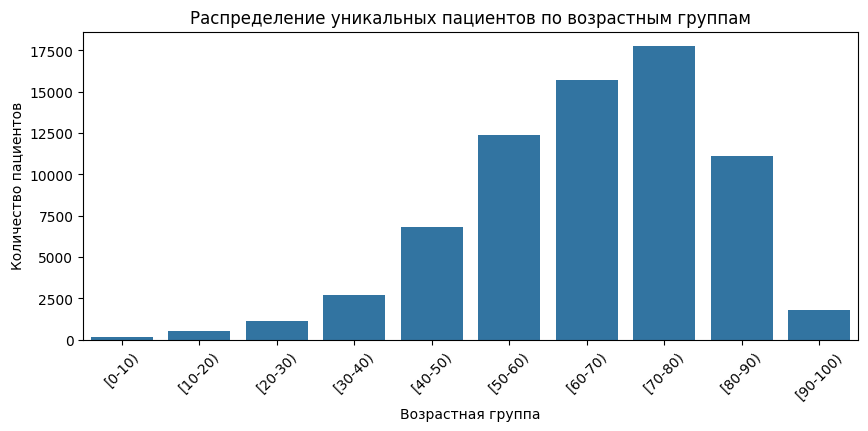

In [444]:
plt.figure(figsize=(10, 4))

sns.countplot(data=patient_demo, x='age', order=age_order)

plt.title('Распределение уникальных пациентов по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Количество пациентов')
plt.xticks(rotation=45)

plt.show()

In [445]:
age_again = patient_demo.groupby('age')['readmitted_30'].mean() * 100


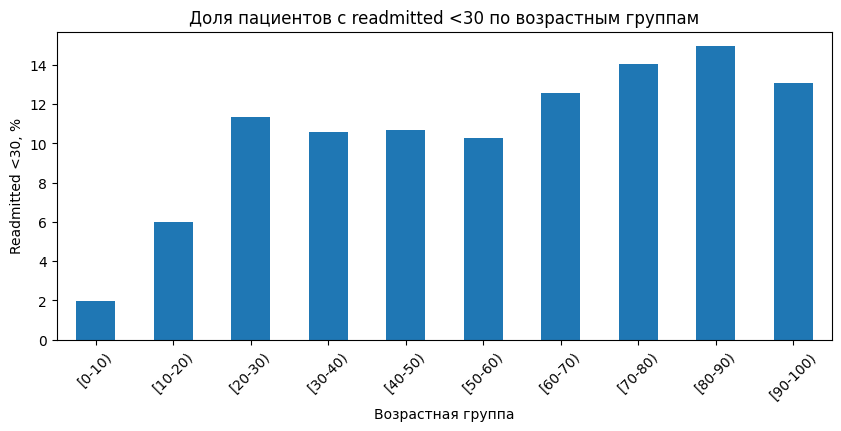

In [446]:
plt.figure(figsize=(10, 4))

age_again.plot(kind='bar')

plt.title('Доля пациентов с readmitted <30 по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Readmitted <30, %')
plt.xticks(rotation=45)

plt.show()

На первом графике показано распределение уникальных пациентов по возрастным группам. Видно, что в датасете преобладают пациенты старших возрастных групп.

На втором графике показана доля уникальных пациентов, у которых хотя бы раз была ранняя повторная госпитализация

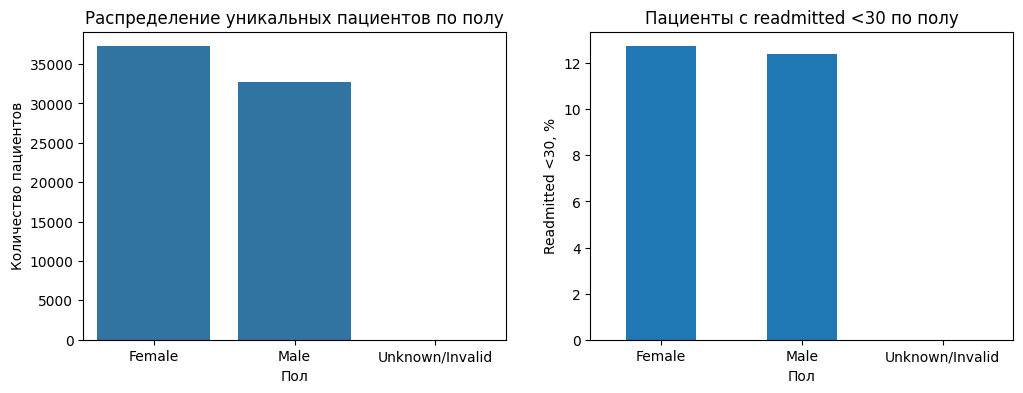

In [447]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=patient_demo, x='gender', ax=axes[0])
axes[0].set_title('Распределение уникальных пациентов по полу')
axes[0].set_xlabel('Пол')
axes[0].set_ylabel('Количество пациентов')

gender_again = patient_demo.groupby('gender')['readmitted_30'].mean() * 100

gender_again.plot(kind='bar', ax=axes[1])
axes[1].set_title('Пациенты с readmitted <30 по полу')
axes[1].set_xlabel('Пол')
axes[1].set_ylabel('Readmitted <30, %')
axes[1].tick_params(axis='x', rotation=0)

plt.show()

На уровне уникальных пациентов распределение по полу показывает, сколько мужчин и женщин представлено в датасете без повторного учёта одного и того же пациента.

Правый график показывает долю пациентов каждого пола, у которых хотя бы раз была ранняя повторная госпитализация

**Рассмотрим основные числовые признаки**

Разделили числовые признаки на две группы.

Первая группа описывает **текущую госпитализацию**:
- time_in_hospital - сколько дней пациент провёл в больнице;
- num_lab_procedures - количество лабораторных процедур;
- num_procedures - количество других процедур;
- num_medications - количество назначенных лекарств;
- number_diagnoses - количество диагнозов.

Вторая группа описывает **предыдущую медицинскую активность пациента**:
- number_outpatient - количество outpatient-визитов за предыдущий год
- number_emergency - количество emergency-визитов за предыдущий год
- number_inpatient - количество inpatient-госпитализаций за предыдущий год.

Такой подход логичен, потому что повторная госпитализация может быть связана как со сложностью текущего случая, так и с тем, насколько часто пациент уже обращался за медицинской помощью раньше

Распределения числовых признаков **текущей госпитализации**

In [448]:
num_current = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses']
num_history = ['number_outpatient', 'number_emergency', 'number_inpatient']

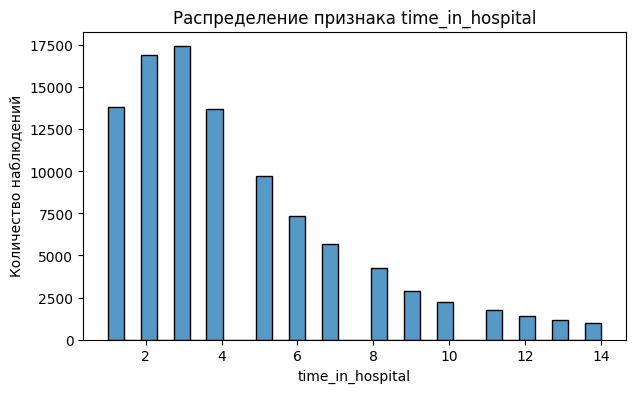

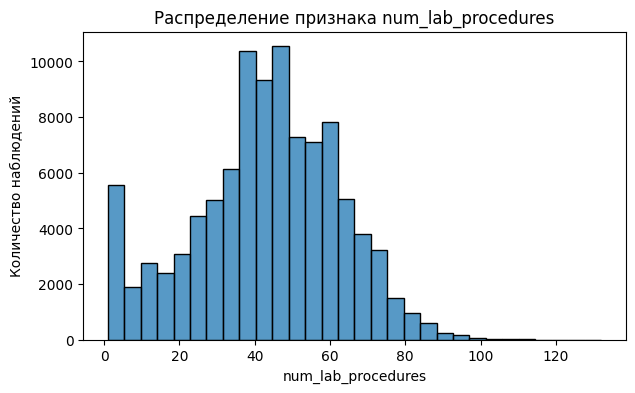

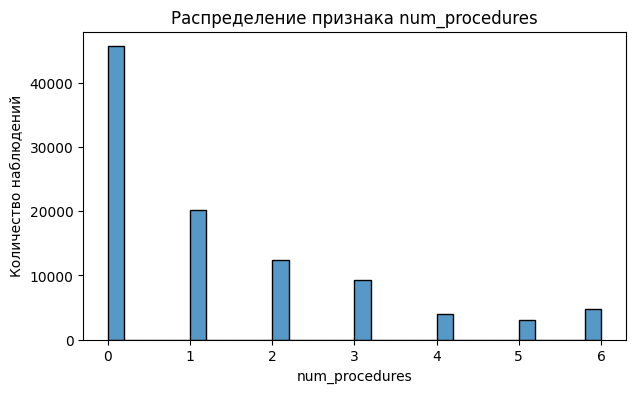

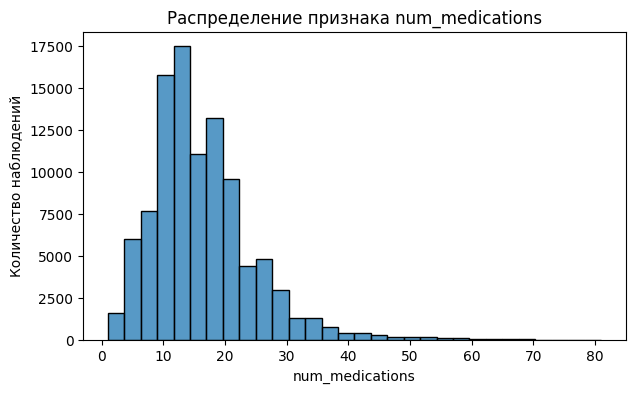

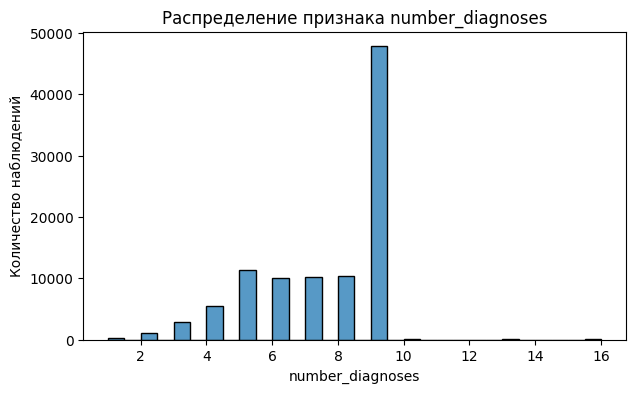

In [449]:
for col in num_current:
    plt.figure(figsize=(7, 4))

    sns.histplot(data=df, x=col, bins=30)

    plt.title(f'Распределение признака {col}')
    plt.xlabel(col)
    plt.ylabel('Количество наблюдений')

    plt.show()

По графикам видно, что большинство госпитализаций были недолгими, чаще всего пациенты находились в больнице от 1 до 4 дней.

Количество лабораторных процедур чаще всего находится в среднем диапазоне, примерно от 30 до 60. Очень большие значения встречаются редко.

Для num_procedures заметно, что чаще всего значение равно 0. Это означает, что у многих пациентов не было дополнительных процедур, кроме лабораторных.

Количество назначенных лекарств чаще всего находится примерно в диапазоне от 10 до 20, но есть пациенты с гораздо большим числом препаратов. Это может говорить о более сложном лечении.

Для number_diagnoses особенно часто встречается значение 9. Это может быть связано как с медицинской сложностью пациентов, так и с особенностями заполнения данных.

Таким образом, числовые признаки показывают разную степень сложности госпитализации. Поэтому дальше их можно сравнить с readmitted_30, чтобы понять, связана ли сложность случая с ранней повторной госпитализацией

**Признаки прошлых обращений пациента**

In [450]:
df[num_history].describe()

,number_outpatient,number_emergency,number_inpatient
count,99343.000000,99343.000000,99343.000000
mean,0.369246,0.198444,0.630935
std,1.265142,0.937734,1.260428
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,1.000000
max,42.000000,76.000000,21.000000


По таблице describe видно, что у этих признаков значения небольшие или равны 0, но есть пациенты с большим количеством прошлых обращений. Поэтому дальше я сгруппирую значения в более понятные категории: 0, 1, 2 и 3+ обращений

In [451]:
df['outpatient_group'] = pd.cut(df['number_outpatient'], bins=[-1, 0, 1, 2, 100], labels=['0', '1', '2', '3+'])

df['emergency_group'] = pd.cut(df['number_emergency'], bins=[-1, 0, 1, 2, 100], labels=['0', '1', '2', '3+'])

df['inpatient_group'] = pd.cut(df['number_inpatient'], bins=[-1, 0, 1, 2, 100], labels=['0', '1', '2', '3+'])

Такой подход делает анализ более понятным, потому что большие значения встречаются редко, и их удобнее рассматривать как отдельную общую группу

In [452]:
df['outpatient_group'].value_counts().sort_index(), df['emergency_group'].value_counts().sort_index(), df['inpatient_group'].value_counts().sort_index()

(outpatient_group
 0     82994
 1      8349
 2      3509
 3+     4491
 Name: count, dtype: int64,
 emergency_group
 0     88249
 1      7474
 2      1984
 3+     1636
 Name: count, dtype: int64,
 inpatient_group
 0     66245
 1     18984
 2      7300
 3+     6814
 Name: count, dtype: int64)

По результатам видно, что самая большая группа по каждому признаку это пациенты без прошлых обращений. Однако также есть пациенты с 1, 2 и 3+ прошлыми обращениями.

Именно эти группы интересно сравнить между собой: можно проверить, растёт ли доля ранней повторной госпитализации у пациентов с большим количеством прошлых обращений

In [453]:
outpatient_table = df.groupby('outpatient_group', observed=False)['readmitted_30'].mean() * 100
emergency_table = df.groupby('emergency_group', observed=False)['readmitted_30'].mean() * 100
inpatient_table = df.groupby('inpatient_group', observed=False)['readmitted_30'].mean() * 100

In [454]:
history = pd.DataFrame({
    'outpatient': outpatient_table,
    'emergency': emergency_table,
    'inpatient': inpatient_table})

history

,outpatient,emergency,inpatient
0,10.891149,10.686807,8.589327
1,14.205294,14.677549,13.253266
2,14.078085,18.750000,17.931507
3+,13.248720,25.305623,26.401526


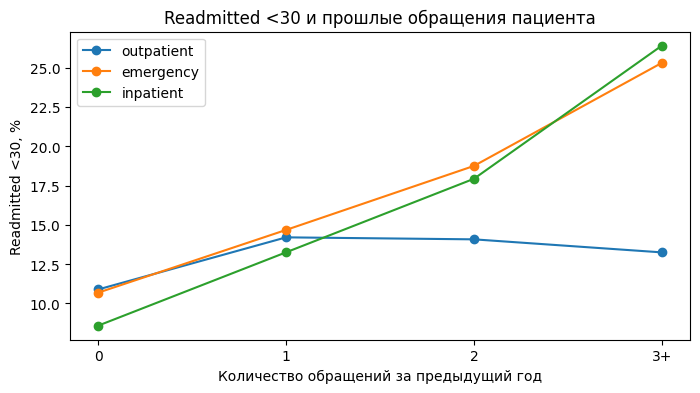

In [455]:
plt.figure(figsize=(8, 4))

plt.plot(history.index.astype(str), history['outpatient'], marker='o', label='outpatient')

plt.plot(history.index.astype(str), history['emergency'], marker='o', label='emergency')

plt.plot(history.index.astype(str), history['inpatient'], marker='o', label='inpatient')

plt.title('Readmitted <30 и прошлые обращения пациента')
plt.xlabel('Количество обращений за предыдущий год')
plt.ylabel('Readmitted <30, %')
plt.legend()

plt.show()

Линейный график показывает, как меняется доля readmitted_30 при увеличении количества прошлых обращений

Теперь сравним числовые признаки у двух групп:

readmitted_30 = 0 - не было ранней повторной госпитализации;
readmitted_30 = 1 - была ранняя повторная госпитализация.

Сможем понять отличаются ли пациенты с ранним возвращением в больницу по сложности текущей госпитализации и по истории прошлых обращений

In [456]:
num_cols = num_current + num_history

df.groupby('readmitted_30')[num_cols].mean().T

readmitted_30,0,1
time_in_hospital,4.329437,4.767545
num_lab_procedures,42.737893,44.222114
num_procedures,1.340854,1.282747
num_medications,15.859558,16.908874
number_diagnoses,7.364425,7.691798
number_outpatient,0.360552,0.436892
number_emergency,0.177975,0.357698
number_inpatient,0.554874,1.222733


По таблице средних значений можно сделать первый вывод: пациенты с readmitted_30 = 1 в среднем имеют больше прошлых inpatient- и emergency-обращений.

Также у них могут быть немного выше значения time_in_hospital, num_medications и number_diagnoses. Это говорит о том, что ранняя повторная госпитализация может быть связана как с более сложной текущей госпитализацией, так и с более тяжёлой медицинской историей пациента

In [457]:
cols = ['time_in_hospital', 'num_medications', 'number_diagnoses', 'number_inpatient']

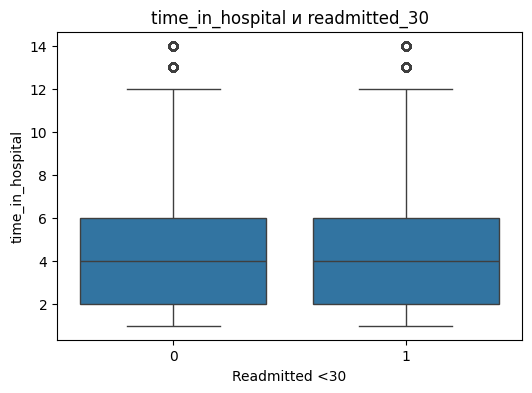

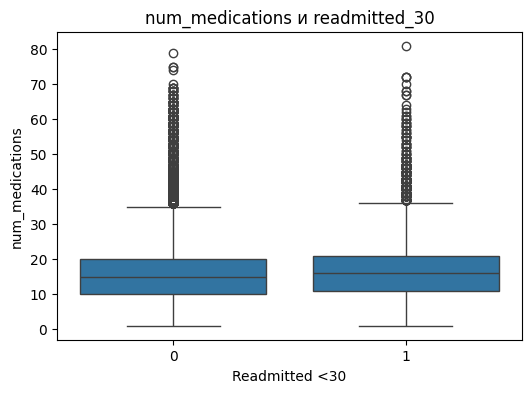

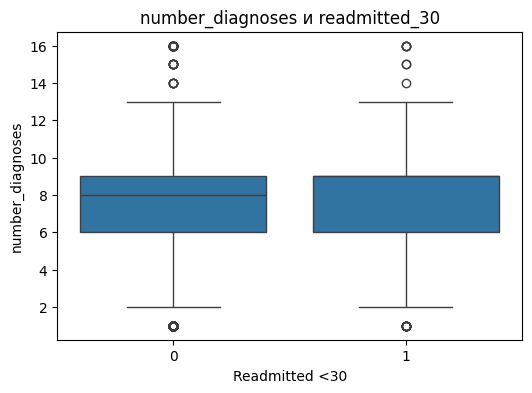

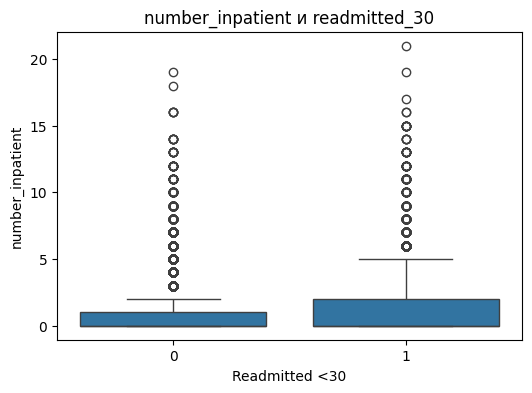

In [458]:
for col in cols:
    plt.figure(figsize=(6, 4))

    sns.boxplot(data=df, x='readmitted_30', y=col)

    plt.title(f'{col} и readmitted_30')
    plt.xlabel('Readmitted <30')
    plt.ylabel(col)

    plt.show()

Boxplot показывает распределение признаков в двух группах (с ранней повторной госпитализацией и без неё)

Для time_in_hospital и num_medications можно проверить, связаны ли более длительное пребывание в больнице и более сложная лекарственная терапия с ранним возвращением пациента.

Для number_diagnoses можно посмотреть, отличаются ли пациенты с большим количеством диагнозов.

у пациентов с readmitted_30 = 1 значения number_inpatient в целом выше, чем у пациентов с readmitted_30 = 0. Это значит, что пациенты с ранней повторной госпитализацией чаще имели госпитализации за предыдущий год

**Анализ признаков лечения диабета**

Теперь рассмотрим признаки, связанные с лечением диабета.

Для анализа возьму три признака:

insulin - назначался ли инсулин и менялась ли его дозировка;
change - было ли изменение диабетической терапии;
diabetesMed - назначались ли диабетические препараты.

Эти признаки важны, потому что изменение лечения или использование инсулина может быть связано с более сложным или нестабильным состоянием пациента

In [459]:
therapy_cols = ['insulin', 'change', 'diabetesMed']

In [460]:
for col in therapy_cols:
    print(df[col].value_counts())
    print()

insulin
No        46379
Steady    30069
Down      11908
Up        10987
Name: count, dtype: int64

change
No    53221
Ch    46122
Name: count, dtype: int64

diabetesMed
Yes    76719
No     22624
Name: count, dtype: int64



По распределению признаков видно, что категории внутри признаков лечения представлены неравномерно

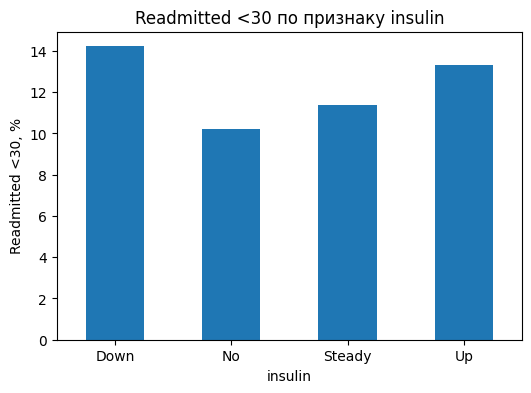

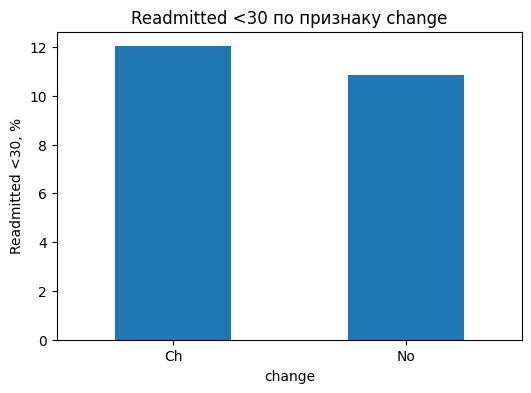

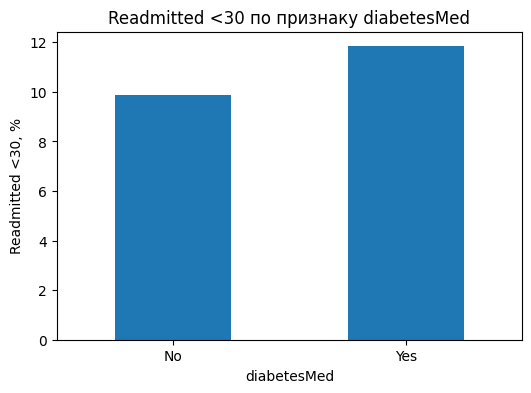

In [461]:
for col in therapy_cols:
    therapy_rate = df.groupby(col)['readmitted_30'].mean() * 100

    plt.figure(figsize=(6, 4))

    therapy_rate.plot(kind='bar')

    plt.title(f'Readmitted <30 по признаку {col}')
    plt.xlabel(col)
    plt.ylabel('Readmitted <30, %')
    plt.xticks(rotation=0)

    plt.show()

По графикам видно, что признаки лечения диабета также связаны с ранней повторной госпитализацией.

Для insulin доля readmitted_30 выше у пациентов, у которых дозировка инсулина менялась. Особенно выделяются категории Up и Down. Это может говорить о том, что изменение дозировки инсулина связано с более нестабильным состоянием пациента.

По признаку change видно, что пациенты с изменением диабетической терапии имеют более высокую долю readmitted_30, чем пациенты без изменения терапии. Это также указывает на возможную связь между сложностью лечения и ранней повторной госпитализацией.

По признаку diabetesMed различия менее выражены

In [462]:
corr_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_diagnoses',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'readmitted_30'
]

In [463]:
corr_matrix = df[corr_cols].corr()
corr_matrix

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,number_outpatient,number_emergency,number_inpatient,readmitted_30
time_in_hospital,1.000000,0.319855,0.189908,0.463757,0.220600,-0.009214,-0.009573,0.074251,0.046886
num_lab_procedures,0.319855,1.000000,0.051715,0.265148,0.149663,-0.007610,-0.000980,0.039908,0.024044
num_procedures,0.189908,0.051715,1.000000,0.381931,0.070460,-0.025263,-0.038715,-0.067021,-0.010841
num_medications,0.463757,0.265148,0.381931,1.000000,0.261639,0.046037,0.014028,0.065266,0.041179
number_diagnoses,0.220600,0.149663,0.070460,0.261639,1.000000,0.094829,0.055994,0.104737,0.053580
number_outpatient,-0.009214,-0.007610,-0.025263,0.046037,0.094829,1.000000,0.091668,0.108015,0.019169
number_emergency,-0.009573,-0.000980,-0.038715,0.014028,0.055994,0.091668,1.000000,0.267702,0.060885
number_inpatient,0.074251,0.039908,-0.067021,0.065266,0.104737,0.108015,0.267702,1.000000,0.168326
readmitted_30,0.046886,0.024044,-0.010841,0.041179,0.053580,0.019169,0.060885,0.168326,1.000000


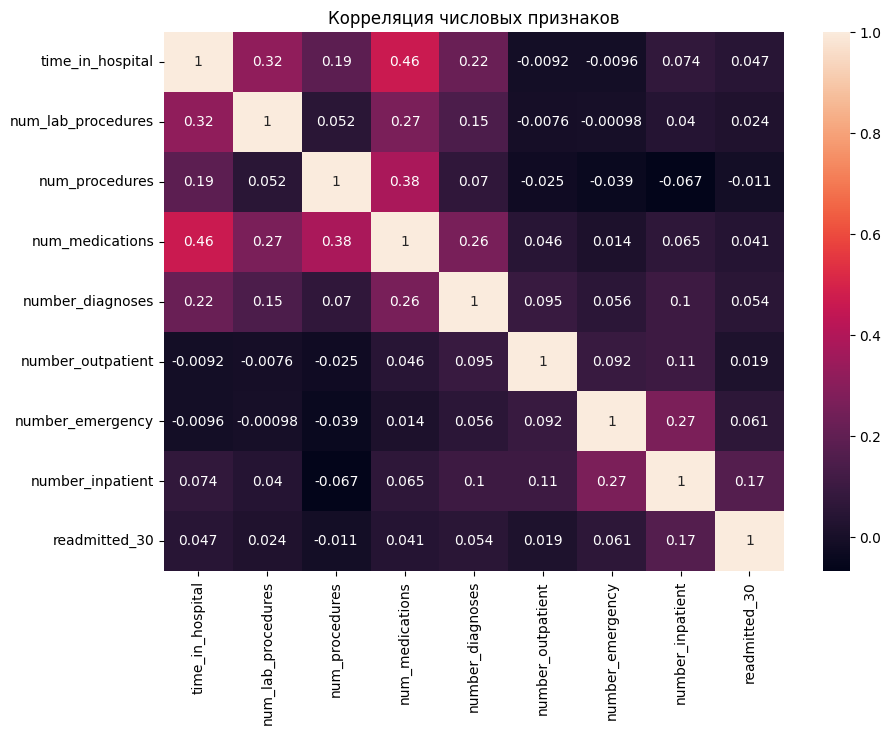

In [464]:
plt.figure(figsize=(10, 7))

sns.heatmap(corr_matrix, annot=True)

plt.title('Корреляция числовых признаков')
plt.show()

По корреляционной матрице видно, что сильных линейных связей с readmitted_30 нет. Это ожидаемо для медицинских данных, потому что ранняя повторная госпитализация зависит сразу от нескольких факторов.

Наиболее заметная положительная связь с readmitted_30 наблюдается у number_inpatient. Это подтверждает предыдущий вывод, что пациенты с прошлыми inpatient-госпитализациями чаще возвращаются в больницу в течение 30 дней.

Более слабая положительная связь также видна у number_emergency, number_diagnoses, time_in_hospital и num_medications. Эти признаки отражают медицинскую историю пациента и сложность текущей госпитализации.

num_procedures почти не связан с readmitted_30, поэтому по результатам EDA этот признак выглядит менее важным

In [465]:
df.num_lab_procedures.describe()

count    99343.000000
mean        42.906929
std         19.610032
min          1.000000
25%         31.000000
50%         44.000000
75%         57.000000
max        132.000000
Name: num_lab_procedures, dtype: float64

In [466]:
df.time_in_hospital.describe()

count    99343.000000
mean         4.379332
std          2.968409
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         14.000000
Name: time_in_hospital, dtype: float64

In [467]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

def safe_divide(x, y):
    try:
        return x / y
    except ZeroDivisionError:
        return np.nan

In [468]:
def delta_var(numerator, denominator):
    """
    Функция для расчета дисперсии дельта-методом, numerator - вектор числитель, denominator - вектор знаменатель
    """
    x = numerator
    y = denominator
    n = len(x)
    mu_x = np.mean(x)
    mu_y = np.mean(y)
    var_x = np.var(x, ddof=1)
    var_y = np.var(y, ddof=1)
    cov_xy = np.cov(x, y, ddof=1)[0][1]    
    delta = safe_divide(safe_divide(var_x,mu_y**2)  - 2*cov_xy*safe_divide(mu_x,mu_y**3) + var_y*safe_divide(mu_x**2,mu_y**4), n)
    return delta


num = 1000
pvalue_tt_delta = []
def delta_method(x_num, x_denom, y_num, y_denom):
    n = len(x_num)
    m = len(y_num)
    test_var = delta_var(x_num, x_denom)
    control_var = delta_var(y_num, y_denom)
    sigma = np.sqrt(test_var + control_var)
    delta_estimator = safe_divide(np.mean(x_num), np.mean(x_denom)) - safe_divide(np.mean(y_num), np.mean(y_denom))
    tt = safe_divide(delta_estimator, sigma)
    pvalue = 2*stats.t.sf(np.abs(tt),n+m-2)
    return tt, pvalue

In [469]:
def linearization_type_1(x_num, x_denom, y_num, y_denom):
    y_num_bar = np.mean(y_num)
    y_denom_bar = np.mean(y_denom)
    y_estimator = safe_divide(y_num_bar, y_denom_bar)
    x_linear = np.array(x_num) - y_estimator*np.array(x_denom)
    y_linear = np.array(y_num) - y_estimator*np.array(y_denom)
    t_stat, p_value = stats.ttest_ind(x_linear, y_linear, equal_var=False)
    return t_stat, p_value

def linearization_type_2(x_num, x_denom, y_num, y_denom):
    x_num_bar = np.mean(x_num)
    y_num_bar = np.mean(y_num)
    x_denom_bar = np.mean(x_denom)
    y_denom_bar = np.mean(y_denom)
    x_estimator = safe_divide(x_num_bar, x_denom_bar)
    y_estimator = safe_divide(y_num_bar, y_denom_bar)
    x_linear = x_estimator  + safe_divide(1, x_denom_bar)*(np.array(x_num) - x_estimator*np.array(x_denom))
    y_linear = y_estimator  + safe_divide(1, y_denom_bar)*(np.array(y_num) - y_estimator*np.array(y_denom))
    t_stat, p_value = stats.ttest_ind(x_linear, y_linear, equal_var=False)
    return t_stat, p_value

## Синтетический A/B тест

Генератор, откалиброванный под реальные распределения датасета:
- `num_lab_procedures` — Normal(42.9, 19.6), дискретный, clip [1, 132]
- `time_in_hospital` — отрицательное биномиальное (var > mean → overdispersed), clip [1, 14]

`effect` — мультипликативный эффект на среднее тестовой группы (например, `0.05` = +5%)

In [470]:
def ab_sample(
    num_users: int = 10000,
    effect: float = 0.0,
    seed: int = None
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Генератор синтетических данных для A/B теста.

    Параметры
    ---------
    num_users : int
        Число пользователей в каждой группе.
    effect : float
        Мультипликативный эффект на тестовую группу (0.05 = +5% к среднему).
    seed : int | None
        Для воспроизводимости.

    Возвращает
    ----------
    control_lab, treatment_lab   — num_lab_procedures для двух групп
    control_time, treatment_time — time_in_hospital для двух групп
    """
    rng = np.random.default_rng(seed)

    # --- num_lab_procedures ---
    # По данным: mean=42.9, std=19.6, min=1, max=132, форма близка к нормальной
    lab_mean = 42.906
    lab_std  = 19.610

    control_lab = np.clip(
        rng.normal(lab_mean, lab_std, size=num_users).round().astype(int),
        1, 132
    )
    treatment_lab = np.clip(
        rng.normal(lab_mean * (1 + effect), lab_std, size=num_users).round().astype(int),
        1, 132
    )

    # --- time_in_hospital ---
    # По данным: mean=4.38, std=2.97, var=8.81 > mean → overdispersed → NegBin
    # NegBin(r, p): mean = r*(1-p)/p, var = mean + mean^2/r
    # Из данных: r = mean^2 / (var - mean) ≈ 4.33
    time_mean = 4.379
    time_var  = 2.968 ** 2       # ≈ 8.81

    r = time_mean ** 2 / (time_var - time_mean)  # dispersion ≈ 4.33

    def negbin_p(mu: float) -> float:
        return r / (r + mu)

    # numpy negbin генерирует от 0, поэтому clip снизу в 1
    control_time = np.clip(
        rng.negative_binomial(r, negbin_p(time_mean), size=num_users),
        1, 14
    )
    treatment_time = np.clip(
        rng.negative_binomial(r, negbin_p(time_mean), size=num_users),
        1, 14
    )

    return control_lab, control_time, treatment_lab, treatment_time

In [471]:
# Пример использования: эффект +5% на num_lab_procedures и time_in_hospital
ctrl_lab, ctrl_time, trt_lab, trt_time = ab_sample(num_users=10000, effect=0.05, seed=np.random.randint(0, 100000))

print("=== num_lab_procedures ===")
print(f"control:   mean={ctrl_lab.mean():.2f}, std={ctrl_lab.std():.2f}")
print(f"treatment: mean={trt_lab.mean():.2f}, std={trt_lab.std():.2f}")
print()
print("=== time_in_hospital ===")
print(f"control:   mean={ctrl_time.mean():.2f}, std={ctrl_time.std():.2f}")
print(f"treatment: mean={trt_time.mean():.2f}, std={trt_time.std():.2f}")

=== num_lab_procedures ===
control:   mean=43.32, std=19.44
treatment: mean=45.04, std=19.46

=== time_in_hospital ===
control:   mean=4.42, std=2.89
treatment: mean=4.37, std=2.80


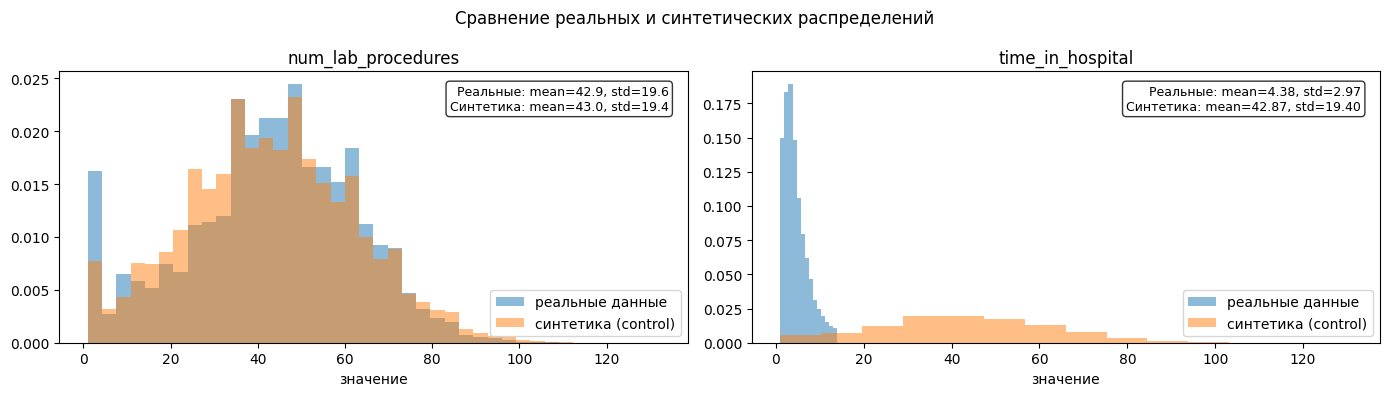

In [472]:
# Проверка: синтетические данные vs реальные (effect=0, т.е. H0 истинна)
ctrl_lab, trt_lab, ctrl_time, trt_time = ab_sample(num_users=50000, effect=0.0, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# num_lab_procedures
axes[0].hist(df['num_lab_procedures'], bins=40, alpha=0.5, density=True, label='реальные данные')
axes[0].hist(ctrl_lab, bins=40, alpha=0.5, density=True, label='синтетика (control)')
axes[0].set_title('num_lab_procedures')
axes[0].legend()
axes[0].set_xlabel('значение')

real_stats = df['num_lab_procedures'].describe()
synt_stats = pd.Series(ctrl_lab).describe()
axes[0].text(0.97, 0.95,
    f"Реальные: mean={real_stats['mean']:.1f}, std={real_stats['std']:.1f}\n"
    f"Синтетика: mean={synt_stats['mean']:.1f}, std={synt_stats['std']:.1f}",
    transform=axes[0].transAxes, ha='right', va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)

# time_in_hospital
axes[1].hist(df['time_in_hospital'], bins=14, alpha=0.5, density=True, label='реальные данные')
axes[1].hist(ctrl_time, bins=14, alpha=0.5, density=True, label='синтетика (control)')
axes[1].set_title('time_in_hospital')
axes[1].legend()
axes[1].set_xlabel('значение')

real_stats2 = df['time_in_hospital'].describe()
synt_stats2 = pd.Series(ctrl_time).describe()
axes[1].text(0.97, 0.95,
    f"Реальные: mean={real_stats2['mean']:.2f}, std={real_stats2['std']:.2f}\n"
    f"Синтетика: mean={synt_stats2['mean']:.2f}, std={synt_stats2['std']:.2f}",
    transform=axes[1].transAxes, ha='right', va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)

plt.suptitle('Сравнение реальных и синтетических распределений')
plt.tight_layout()
plt.show()

## Сравнение мощности: линеаризация 1 vs линеаризация 2 vs дельта-метод

Ratio-метрика: `num_lab_procedures / time_in_hospital` (процедур в день).

Эффект применяется **только к числителю** (lab_procedures), знаменатель (time) одинаковый в обеих группах.

In [473]:
from tqdm import tqdm

n_sizes      = [100, 300, 500, 800, 1000, 1200, 1500, 2000, 4000, 5000]

n_simulations = 1000
effect        = 0.05
alpha         = 0.05

power_lin1  = []
power_lin2  = []
power_delta = []

for n in n_sizes:
    cnt_lin1 = cnt_lin2 = cnt_delta = 0

    for _ in tqdm(range(n_simulations), desc=f'n={n}'):
        x_num, x_denom, y_num, y_denom = ab_sample(n, effect=effect)

        _, p1 = linearization_type_1(x_num, x_denom, y_num, y_denom)
        _, p2 = linearization_type_2(x_num, x_denom, y_num, y_denom)
        _, p3 = delta_method(x_num, x_denom, y_num, y_denom)

        if p1 < alpha: cnt_lin1  += 1
        if p2 < alpha: cnt_lin2  += 1
        if p3 < alpha: cnt_delta += 1

    power_lin1 .append(cnt_lin1  / n_simulations)
    power_lin2 .append(cnt_lin2  / n_simulations)
    power_delta.append(cnt_delta / n_simulations)

n=5000: 100%|██████████| 1000/1000 [00:01<00:00, 843.46it/s]


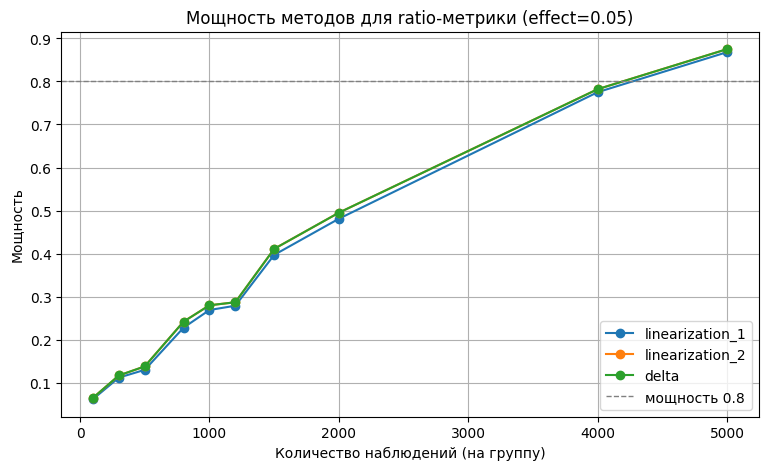

In [475]:
plt.figure(figsize=(9, 5))

plt.plot(n_sizes, power_lin1,  marker='o', label='linearization_1')
plt.plot(n_sizes, power_lin2,  marker='o', label='linearization_2')
plt.plot(n_sizes, power_delta, marker='o', label='delta')

plt.axhline(0.8, color='gray', linestyle='--', linewidth=1, label='мощность 0.8')

plt.xlabel('Количество наблюдений (на группу)')
plt.ylabel('Мощность')
plt.title(f'Мощность методов для ratio-метрики (effect={effect})')
plt.legend()
plt.grid(True)
plt.show()

ура-ура, берем вторую лиреаризацию! Но сначала проверим его на A/A тестах на группах

In [476]:
from scipy.special import betainc

def ci(
    pvalue_vector: np.array,
    alpha=0.05
) -> tuple[float, float, float]:
    n = len(pvalue_vector)
    n_critical = np.sum(pvalue_vector <= alpha)
    p = n_critical / n
    var = p * (1 - p) / n
    scale = stats.norm.ppf(1-alpha/2)
    eps = np.sqrt(var) * scale
    left_bound = p - eps
    right_bound = p + eps
    return p, left_bound, right_bound


def ks_uniformity_check(
    pvalue_vector: np.ndarray,
):
    n = len(pvalue_vector)
    sorted_pvals = np.sort(pvalue_vector)
    theoretical_cdf = sorted_pvals

    d_plus  = np.max(np.arange(1, n + 1) / n - theoretical_cdf)
    d_minus = np.max(theoretical_cdf - np.arange(0, n) / n)

    print(d_plus.shape)

    D_n = max(d_plus, d_minus)
    lam = np.sqrt(n) * D_n

    p_value = 2 * sum(
        ((-1) ** (k - 1)) * np.exp(-2 * k**2 * lam**2)
        for k in range(1, 100) 
    )
    p_value = np.clip(p_value, 0, 1)

    # ks_stat, ks_pval = stats.kstest(pvalue_vector, 'uniform', args=(0, 1))
    # assert np.isclose(D_n, ks_stat, atol=1e-6) \
    #        and np.isclose(ks_pval, p_value, atol=1e-2), f"something went wrong {D_n, ks_stat, p_value, ks_pval}"

    return D_n, p_value


def plot_comparison_with_uniform(
    pvalue_vector: list,
    title: str,
    aplha=0.05,
    color='orange'
):
    pvalue_vector = np.array(pvalue_vector)
    n = len(pvalue_vector)
    p, left_boundary, right_boundary = ci(pvalue_vector, aplha)
    print(f"Ошибка I рода: {round(p, 4)},\nCI для oшибки I рода: [{round(left_boundary, 4)}, {round(right_boundary, 4)}]")

    _, ax1 = plt.subplots(1, 3, figsize=(17, 5))

    # Гистограмма P-value
    ax1[0].hist(pvalue_vector, bins=30, edgecolor='black', alpha=0.6, color=color)
    ax1[0].set_title(
        f'распределение P-value'
    )
    ax1[0].set_xlabel('P-value')
    ax1[0].set_ylabel('Частота')

    # QQ-график
    stats.probplot(pvalue_vector, dist=stats.uniform, plot=ax1[1])
    ax1[1].get_lines()[1].set_linestyle('--')
    ax1[1].set_title(f'{title} (QQ-график)')

    # Эмпирическая функция распределения
    sorted_pvalue_vector = sorted(pvalue_vector)
    ordinal_positions = np.arange(1, n+1) / n
    x_uniform = np.linspace(0, 1, 100)
    cdf_uniform = x_uniform

    ax1[2].step(sorted_pvalue_vector, ordinal_positions, where='post', label='Эмпирическая ФР', color=color)
    ax1[2].plot(x_uniform, cdf_uniform, 'k--', label='Теоретическая CDF $U[0,1]$')
    ax1[2].set_title('Эмпирическая и теоретическая ФР')
    ax1[2].set_xlabel('p-value')
    ax1[2].set_ylabel('dist(p-value)')

    # Тест Колмогорова-Смирнова
    ks_statistic, ks_p_value = ks_uniformity_check(pvalue_vector)
    print(f'Статистика Колмогорова-Смирнова: {round(ks_statistic, 4)}, pvalue для сравнения ЭФР с равномерным: {round(ks_p_value, 4)}')
    if ks_p_value < 0.05:
        print("Гипотеза H0 отвергается: выборка НЕ из равномерного U(0,1)")
    else:
        print("Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)")

    ax1[2].text(
        0.05, 0.9,
        f"KS: stat={ks_statistic:.3f}\np={ks_p_value:.3f}",
        fontsize=10,
        verticalalignment='top',
        bbox={"boxstyle": "round", "facecolor": "w"}
    )
    plt.tight_layout()
    plt.show()


def student_ttest(test_event: np.ndarray, control_event: np.ndarray) -> tuple[float, float]:
    n1, n2 = len(test_event), len(control_event)
    df = n1 + n2 - 2
    mean1, mean2 = np.mean(test_event), np.mean(control_event)

    var1 = np.sum((test_event - mean1)**2) / (n1 - 1)
    var2 = np.sum((control_event - mean2)**2) / (n2 - 1)
    var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)

    t_stat = (mean1 - mean2) / np.sqrt(var * (1/n1 + 1/n2))
    p_value = betainc(df / 2, 0.5, df / (df + t_stat**2))

    ts, tpval = stats.ttest_ind(test_event, control_event)
    assert np.isclose(t_stat, ts) and np.isclose(tpval, p_value), f"{t_stat, ts, tpval, p_value}"
    return t_stat, p_value


def welch_ttest(test_event: np.ndarray, control_event: np.ndarray) -> tuple[float, float]:
    n1, n2 = len(test_event), len(control_event)
    
    mean1, mean2 = np.mean(test_event), np.mean(control_event)

    var1 = np.sum((test_event - mean1)**2) / (n1 - 1)
    var2 = np.sum((control_event - mean2)**2) / (n2 - 1)
    var = var1 / n1 + var2 / n2

    df = var**2 / ((var1/n1)**2/(n1-1) + (var2/n2)**2/(n2-1)) 

    t_stat = (mean1 - mean2) / np.sqrt(var)
    p_value = betainc(df / 2, 0.5, df / (df + t_stat**2))

    ts, tpval = stats.ttest_ind(test_event, control_event, equal_var=False)
    assert np.isclose(t_stat, ts) and np.isclose(tpval, p_value), f"{t_stat, ts, tpval, p_value}"
    return t_stat, p_value


In [485]:
n = 2000

num_male = df.loc[(data["gender"] == "Male"), "num_lab_procedures"]
denom_male = df.loc[(data["gender"] == "Male"), "time_in_hospital"]
pval_lin2 = []

for i in range(n):
    indices = np.random.binomial(1, 0.5, len(num_male)).astype(bool)
    control_num = num_male.loc[indices]
    control_denom = denom_male.loc[indices]
    treatment_num = num_male.loc[~indices]
    treatment_denom = denom_male.loc[~indices]
    _, p_val_c = linearization_type_2(control_num, control_denom, treatment_num, treatment_denom)
    pval_lin2.append(p_val_c)

Ошибка I рода: 0.0535,
CI для oшибки I рода: [0.0436, 0.0634]
()
Статистика Колмогорова-Смирнова: 0.0211, pvalue для сравнения ЭФР с равномерным: 0.3335
Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)


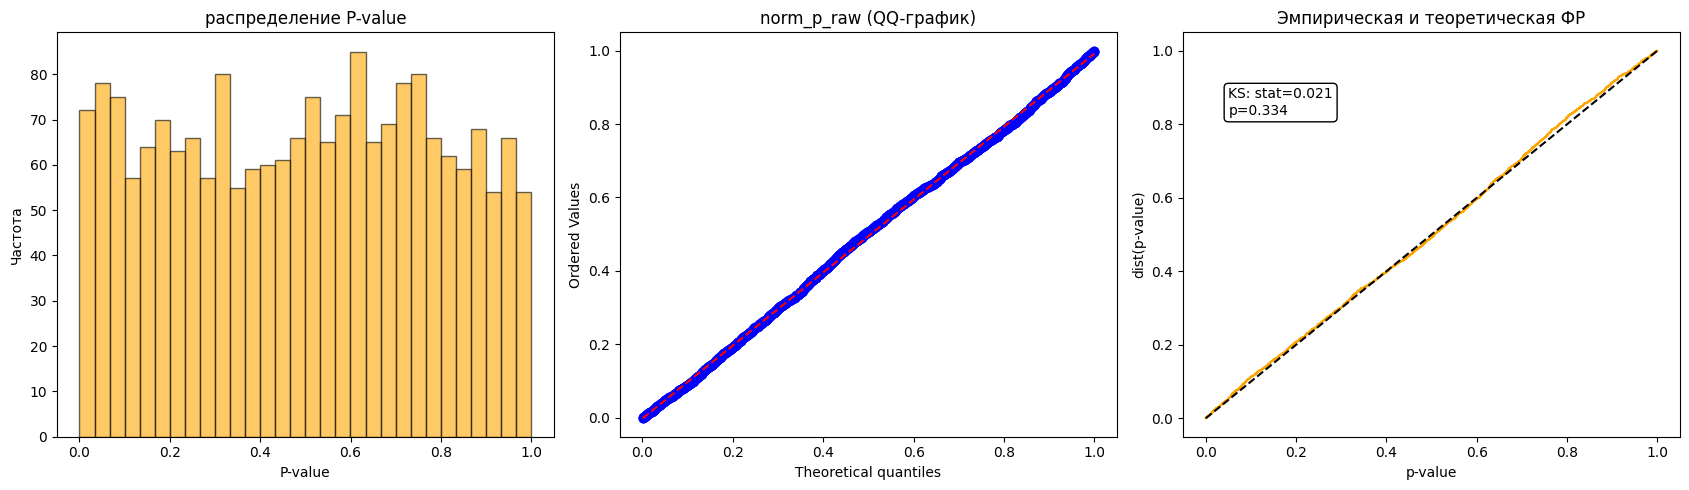

In [486]:
plot_comparison_with_uniform(pval_lin2, "norm_p_raw")

In [483]:
n = 2000

num_female = df.loc[(data["gender"] == "Female"), "num_lab_procedures"]
denom_female = df.loc[(data["gender"] == "Female"), "time_in_hospital"]
pval_lin2_female = []

for i in range(n):
    indices = np.random.binomial(1, 0.5, len(num_female)).astype(bool)
    control_num = num_female.loc[indices]
    control_denom = denom_female.loc[indices]
    treatment_num = num_female.loc[~indices]
    treatment_denom = denom_female.loc[~indices]
    _, p_val_c = linearization_type_2(control_num, control_denom, treatment_num, treatment_denom)
    pval_lin2_female.append(p_val_c)

Ошибка I рода: 0.05,
CI для oшибки I рода: [0.0404, 0.0596]
()
Статистика Колмогорова-Смирнова: 0.0154, pvalue для сравнения ЭФР с равномерным: 0.7266
Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)


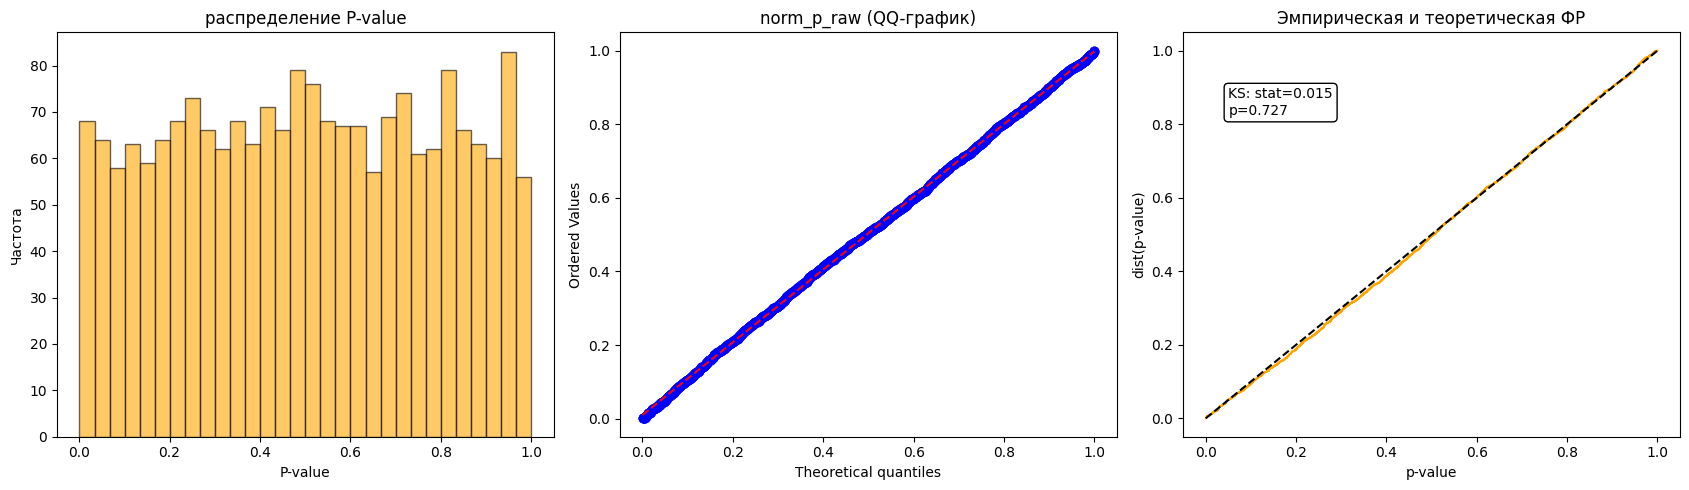

In [484]:
plot_comparison_with_uniform(pval_lin2_female, "norm_p_raw")

## A/B тест с линеризацией 2го типа

In [487]:
t_stat, p_val = linearization_type_2(num_male, denom_male, num_female, denom_female)
t_stat, p_val

(np.float64(8.832731936965592), np.float64(1.0383636142243284e-18))

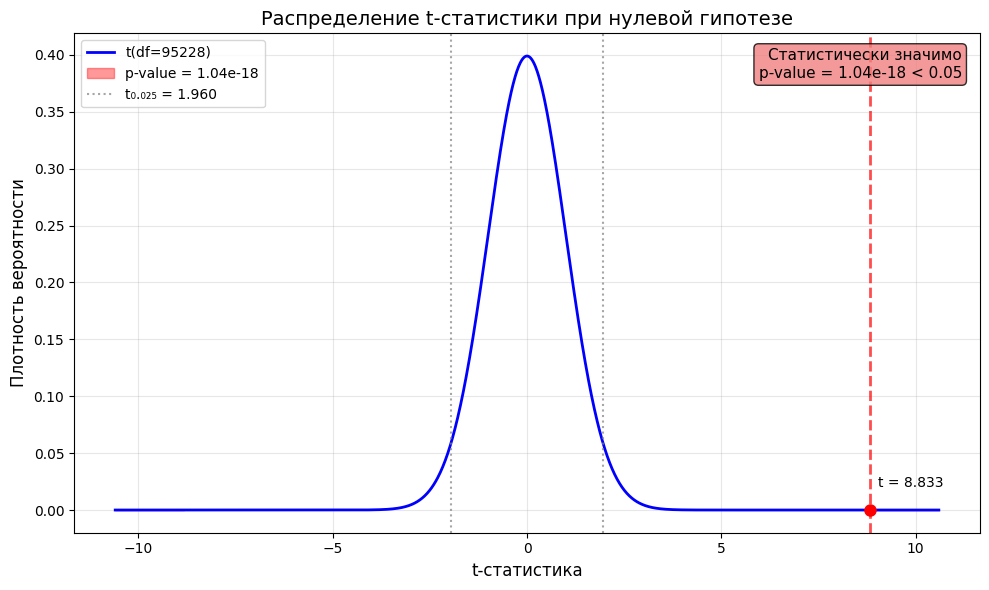

In [489]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.optimize import brentq

df_t = brentq(lambda d: 2 * stats.t.sf(abs(t_stat), d) - p_val, 1, 1e8)

fig, ax = plt.subplots(figsize=(10, 6))
plot_max = max(4.5, abs(t_stat) * 1.2)
x_for_plot = np.linspace(-plot_max, plot_max, 2000)

ax.plot(x_for_plot, stats.t.pdf(x_for_plot, df_t), 'b-', linewidth=2, label=f't(df={df_t:.0f})')

ax.fill_between(x_for_plot, stats.t.pdf(x_for_plot, df_t), 0,
                where=(np.abs(x_for_plot) >= abs(t_stat)),
                color='red', alpha=0.4, label=f'p-value = {p_val:.2e}')

ax.axvline(x=t_stat, color='red', linestyle='--', linewidth=2, alpha=0.7)

ax.plot(t_stat, 0, 'ro', markersize=8)

ax.text(t_stat + 0.2, stats.t.pdf(0, df_t) * 0.05, f't = {t_stat:.3f}', fontsize=10, ha='left')

t_critical = stats.t.ppf(0.975, df_t)
ax.axvline(x=t_critical, color='gray', linestyle=':', linewidth=1.5, alpha=0.7,
           label=f't₀.₀₂₅ = {t_critical:.3f}')
ax.axvline(x=-t_critical, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)

ax.set_xlabel('t-статистика', fontsize=12)
ax.set_ylabel('Плотность вероятности', fontsize=12)
ax.set_title('Распределение t-статистики при нулевой гипотезе', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

if p_val < 0.05:
    result_text = f'Статистически значимо\np-value = {p_val:.2e} < 0.05'
    box_color = 'lightcoral'
else:
    result_text = f'Не значимо\np-value = {p_val:.2e} ≥ 0.05'
    box_color = 'lightgreen'

ax.text(0.98, 0.97, result_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.8))

plt.tight_layout()
plt.show()